In [ ]:
## installing  and importing dependencies

In [ ]:
!pip3 install torch torchvision
!pip install easyocr
!pip install matplotlib

In [15]:
import easyocr
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [11]:
#. 1. Reading Image

In [12]:
IMAGE_PATH = 'ray.png'

In [17]:
img = cv2.imread(IMAGE_PATH)  # Load the image
reader = easyocr.Reader(['en'], gpu= False)
result = reader.readtext(IMAGE_PATH)
h, w, _ = img.shape

# Convert numpy types to native Python types
cleaned_result = []
for bbox, text, score in result:
    # Convert bbox points to regular ints
    clean_bbox = [[int(x), int(y)] for x, y in bbox]
    # Convert score to float and round to 2 decimals
    clean_score = round(float(score), 2)
    cleaned_result.append((clean_bbox, text, clean_score))

print(cleaned_result)

Using CPU. Note: This module is much faster with a GPU.
/opt/anaconda3/envs/ocr/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[([[45, 34], [355, 34], [355, 97], [45, 97]], 'Rayquaza C u73', 0.39), ([[520, 56], [550, 56], [550, 80], [520, 80]], 'HP', 0.79), ([[542, 34], [622, 34], [622, 82], [542, 82]], 'I00', 0.45), ([[54, 96], [120, 96], [120, 124], [54, 124]], 'BASIC', 0.98), ([[80, 476], [130, 476], [130, 532], [80, 532]], '7', 0.58), ([[275, 499], [439, 499], [439, 517], [275, 517]], "Champion'$ Pokemon", 0.87), ([[230, 558], [441, 558], [441, 607], [230, 607]], 'Trash Burst', 1.0), ([[613, 563], [679, 563], [679, 603], [613, 603]], '10+', 0.99), ([[54, 604], [300, 604], [300, 636], [54, 636]], 'You may discard up to 5', 0.81), ([[374, 604], [658, 604], [658, 636], [374, 636]], 'cards from your hand. If you', 0.87), ([[54, 632], [280, 632], [280, 660], [54, 660]], 'do, this attack does /0', 0.78), ([[357, 631], [659, 631], [659, 667], [357, 667]], 'plus I0 more damage for each', 0.98), ([[124, 660], [312, 660], [312, 692], [124, 692]], 'card you discarded:', 0.74), ([[231, 719], [367, 719], [367, 763], [2

In [ ]:
#Drawing the Regions

In [18]:
#pokemon name top left
name_region = img[int(0.03*h):int(0.13*h), int(0.05*w):int(0.6*w)]

In [19]:
#pokemon HP top right
hp_region = img[int(0.02*h):int(0.09*h), int(0.6*w):int(0.9*w)]

In [20]:
#stats: stats
stats_region = img[int(0.95*h):h, int(0.71*w):w]

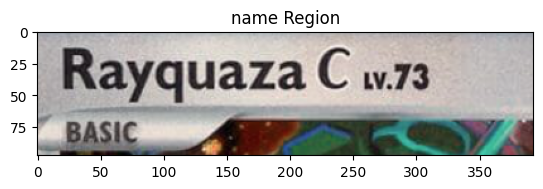

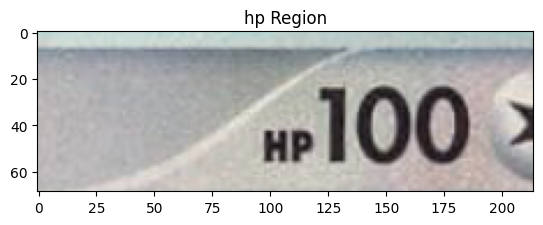

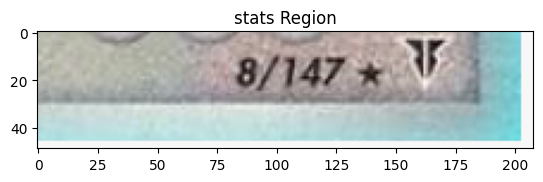

In [21]:
#CRopped images
plt.imshow(name_region)
plt.title("name Region")
plt.show()
plt.imshow(hp_region)
plt.title("hp Region")
plt.show()
plt.imshow(stats_region)
plt.title("stats Region")
plt.show()

In [22]:
#CRopped outputs
name = reader.readtext(name_region, detail=0)
hp = reader.readtext(hp_region, detail=0)
stats = reader.readtext(stats_region, detail=0)

print("Name:", " ".join(name))
print("HP:", " ".join(hp))
print("Stats:", " ".join(stats))

Name: Rayquaza C w73 BASIC
HP: HP 100
Stats: 8/147 * I


In [ ]:
#FUll Image

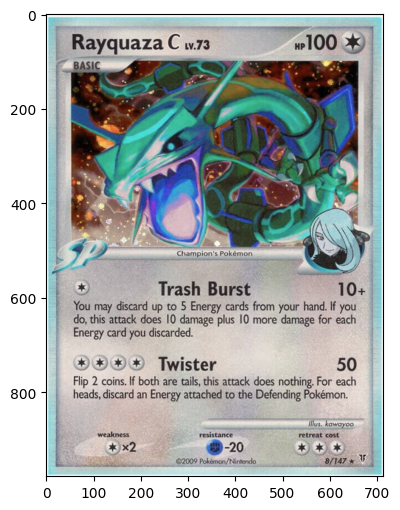

In [23]:

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.show()                      